# Stage 6 — Exploratory Data Analysis

This notebook uses the validated star-schema tables to examine growth, store performance, customer value, product contribution and returns.

## Context and assumptions

- Reported growth includes all stores active in each year.
- Same-store growth uses only the 13 stores with sales in both years.
- Gross product profit excludes operating costs.
- Return rate is a quantity-based proxy because returns cannot be matched to individual sales.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
sys.path.insert(0, str(project_root / "scripts"))
from exploratory_data_analysis import (
    load_model_tables, build_analysis_views, calculate_tables,
    create_charts, build_summary, write_outputs, make_output_directories
)

## Load the model tables

In [2]:
model_tables = load_model_tables(project_root)
sales, returns = build_analysis_views(model_tables)
{name: table.shape for name, table in model_tables.items()}

{'fact_sales': (269720, 16),
 'fact_returns': (7087, 8),
 'dim_date': (737, 15),
 'dim_customer': (10281, 24),
 'dim_product': (1560, 13),
 'dim_store': (24, 17)}

## Build analysis tables and charts

In [3]:
analysis_tables = calculate_tables(sales, returns, model_tables["dim_store"])
reports_dir, images_dir = make_output_directories(project_root)
chart_files = create_charts(analysis_tables, images_dir)
summary = build_summary(sales, returns, analysis_tables)
write_outputs(project_root, analysis_tables, summary, chart_files)
summary

{'total_revenue': 1764546.44,
 'total_gross_product_profit': 1052818.7800000003,
 'gross_margin_pct': 59.665121650184524,
 'quantity_sold': 833489,
 'return_quantity': 8289,
 'return_rate_proxy_pct': 0.9944942284781202,
 'active_customers': 8842,
 'active_stores': 24,
 'reported_revenue_growth_1998_pct': 112.17753126456631,
 'same_store_revenue_growth_1998_pct': 8.40003132838898,
 'reported_profit_growth_1998_pct': 112.2928530943434,
 'same_store_profit_growth_1998_pct': 8.465542266339533,
 'stores_1997': 13,
 'stores_1998': 24,
 'december_1998_revenue': 120160.84,
 'december_1998_vs_monthly_average_pct': 20.23014165556811,
 'store_size_revenue_correlation_1998': -0.10254876832082767,
 'top_store_1998': 'Store 12',
 'top_store_1998_revenue': 87623.61,
 'top_10_customer_revenue_share_pct': 39.886156807525,
 'top_20_customer_revenue_share_pct': 58.1408217286704,
 'highest_revenue_per_customer_membership': 'Golden',
 'highest_membership_revenue_per_customer': 219.7157760314342,
 'lowest_r

## Annual performance

In [4]:
analysis_tables["annual_performance"].round(2)

,year,revenue,gross_product_profit,quantity_sold,active_customers,active_stores,sales_lines,gross_margin_pct,revenue_growth_pct,profit_growth_pct,quantity_growth_pct
0,1997,565238.13,337125.48,266773,5581,13,86837,59.64,NaN,NaN,NaN
1,1998,1199308.31,715693.30,566716,8060,24,182883,59.68,112.18,112.29,112.43


## Reported versus same-store growth

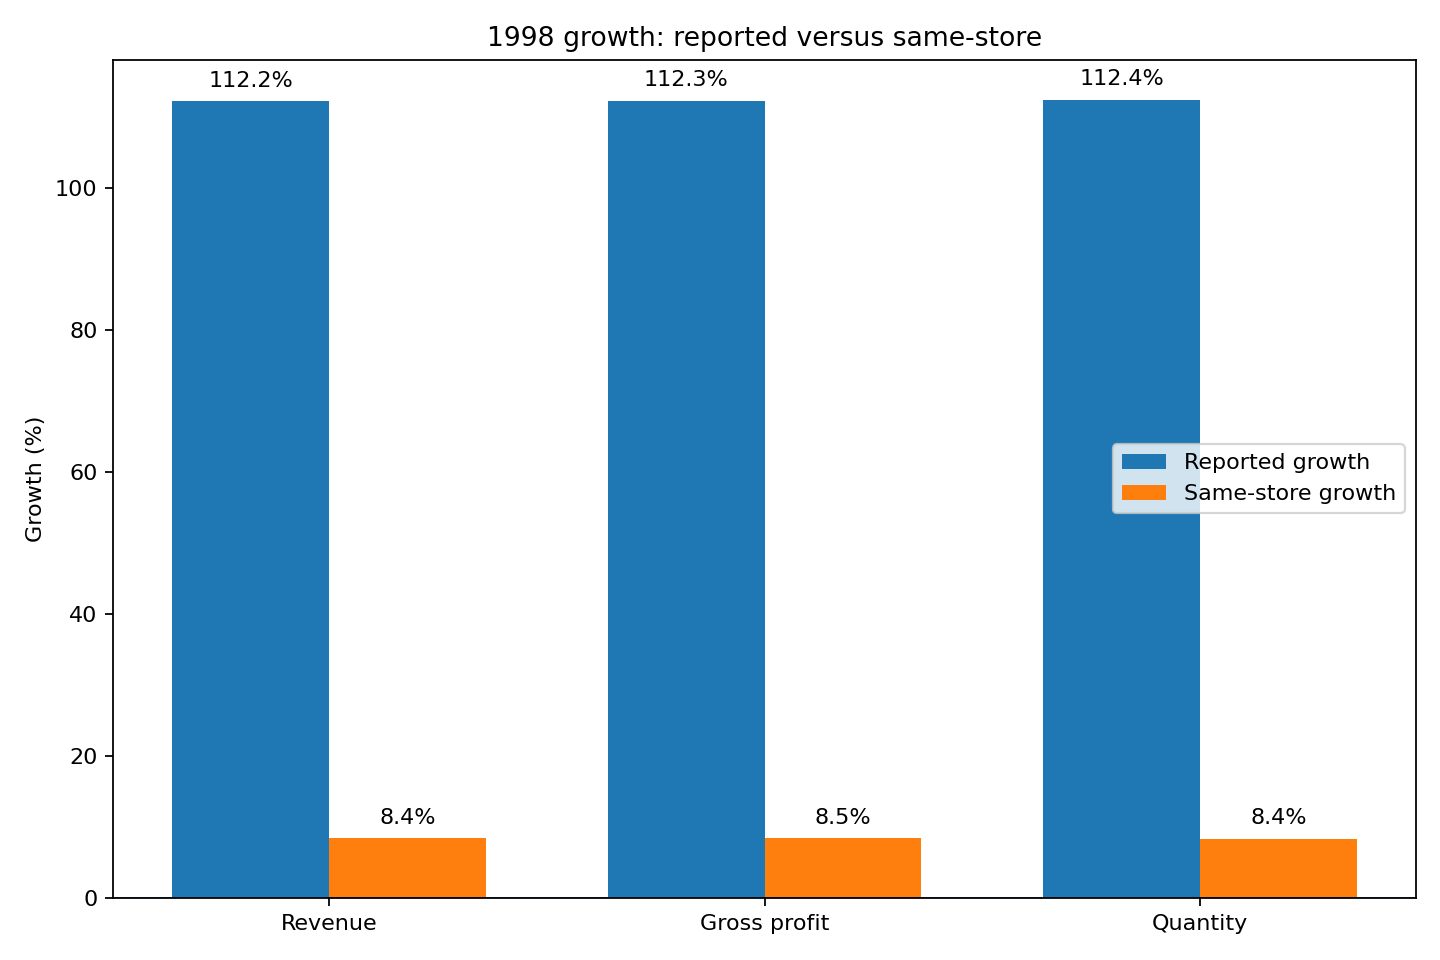

In [5]:
display(Image(filename=str(images_dir / "02_reported_vs_same_store_growth.png")))

## Monthly movement

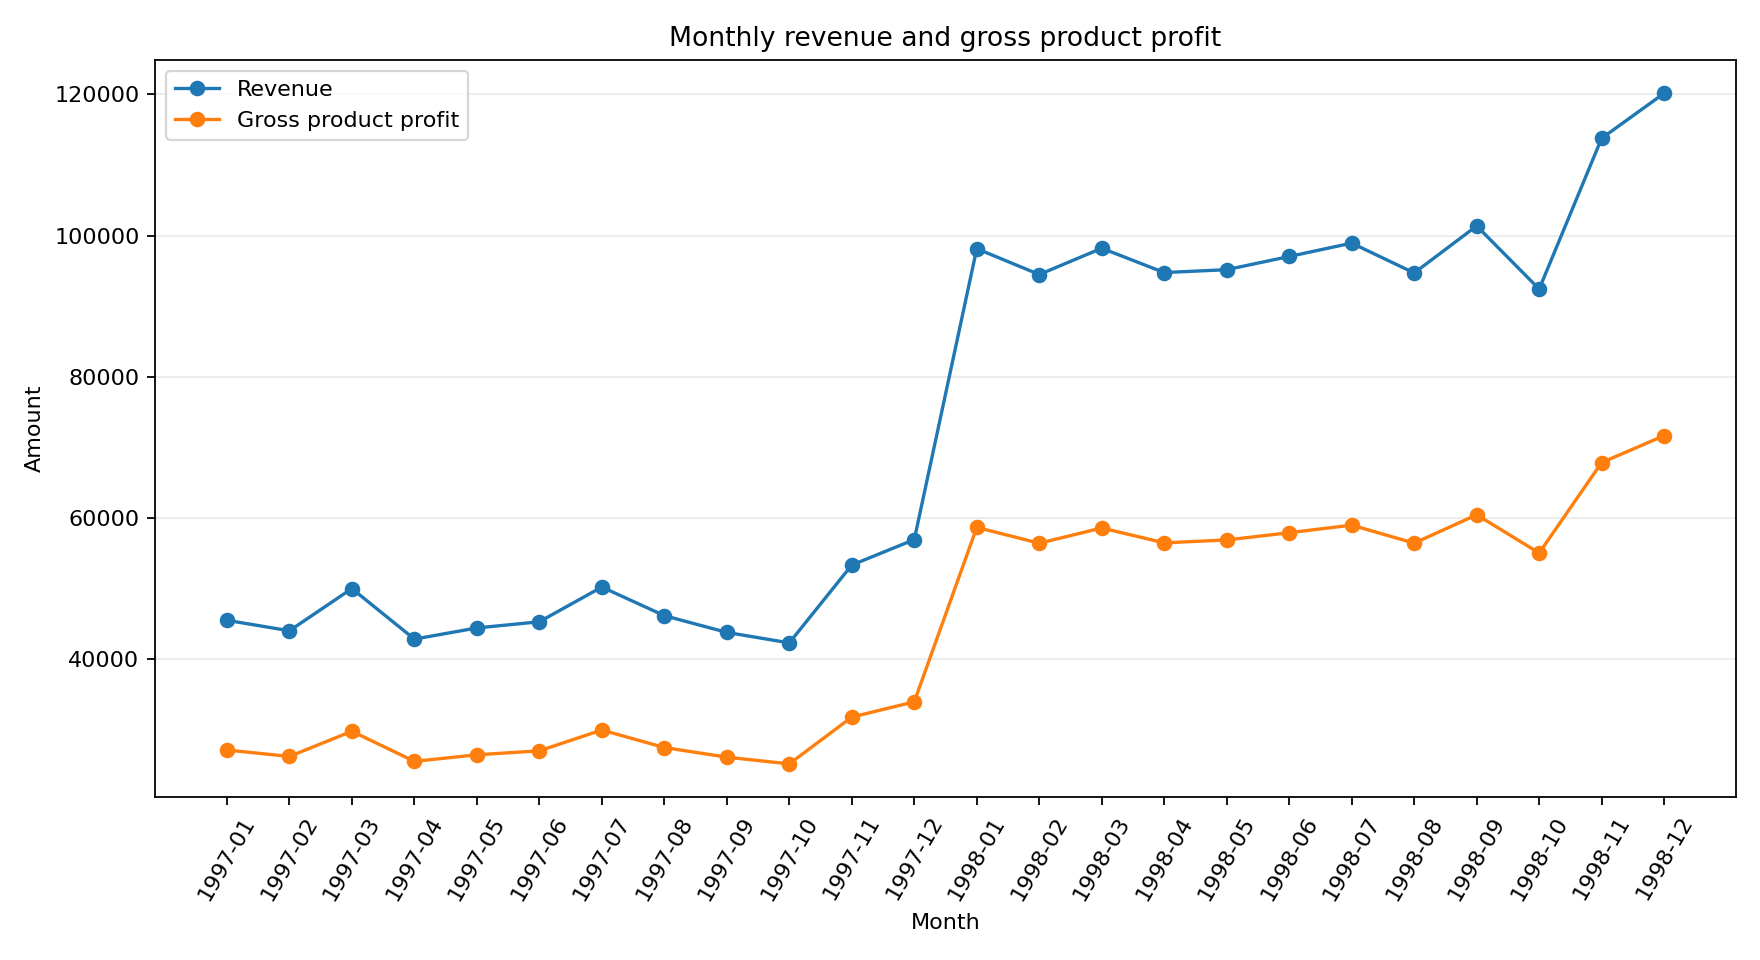

In [6]:
display(Image(filename=str(images_dir / "01_monthly_revenue_profit.png")))

## Store performance

In [7]:
analysis_tables["store_performance_1998"].nlargest(10, "revenue")[["store_name", "store_type", "store_country", "revenue", "revenue_per_sqft", "gross_margin_pct"]].round(2)

,store_name,store_type,store_country,revenue,revenue_per_sqft,gross_margin_pct
11,Store 12,Deluxe Supermarket,Mexico,87623.61,2.87,59.64
7,Store 8,Deluxe Supermarket,Mexico,87253.65,2.83,59.59
18,Store 19,Deluxe Supermarket,Canada,85262.31,3.69,59.76
12,Store 13,Deluxe Supermarket,USA,83180.66,3.00,59.74
16,Store 17,Deluxe Supermarket,USA,82851.94,2.45,59.68
20,Store 21,Deluxe Supermarket,Mexico,81492.24,2.49,59.70
14,Store 15,Supermarket,USA,63337.39,2.99,59.68
15,Store 16,Supermarket,USA,60850.70,2.01,59.73
10,Store 11,Supermarket,USA,60275.83,2.97,59.70
2,Store 3,Supermarket,USA,57981.58,1.46,59.56


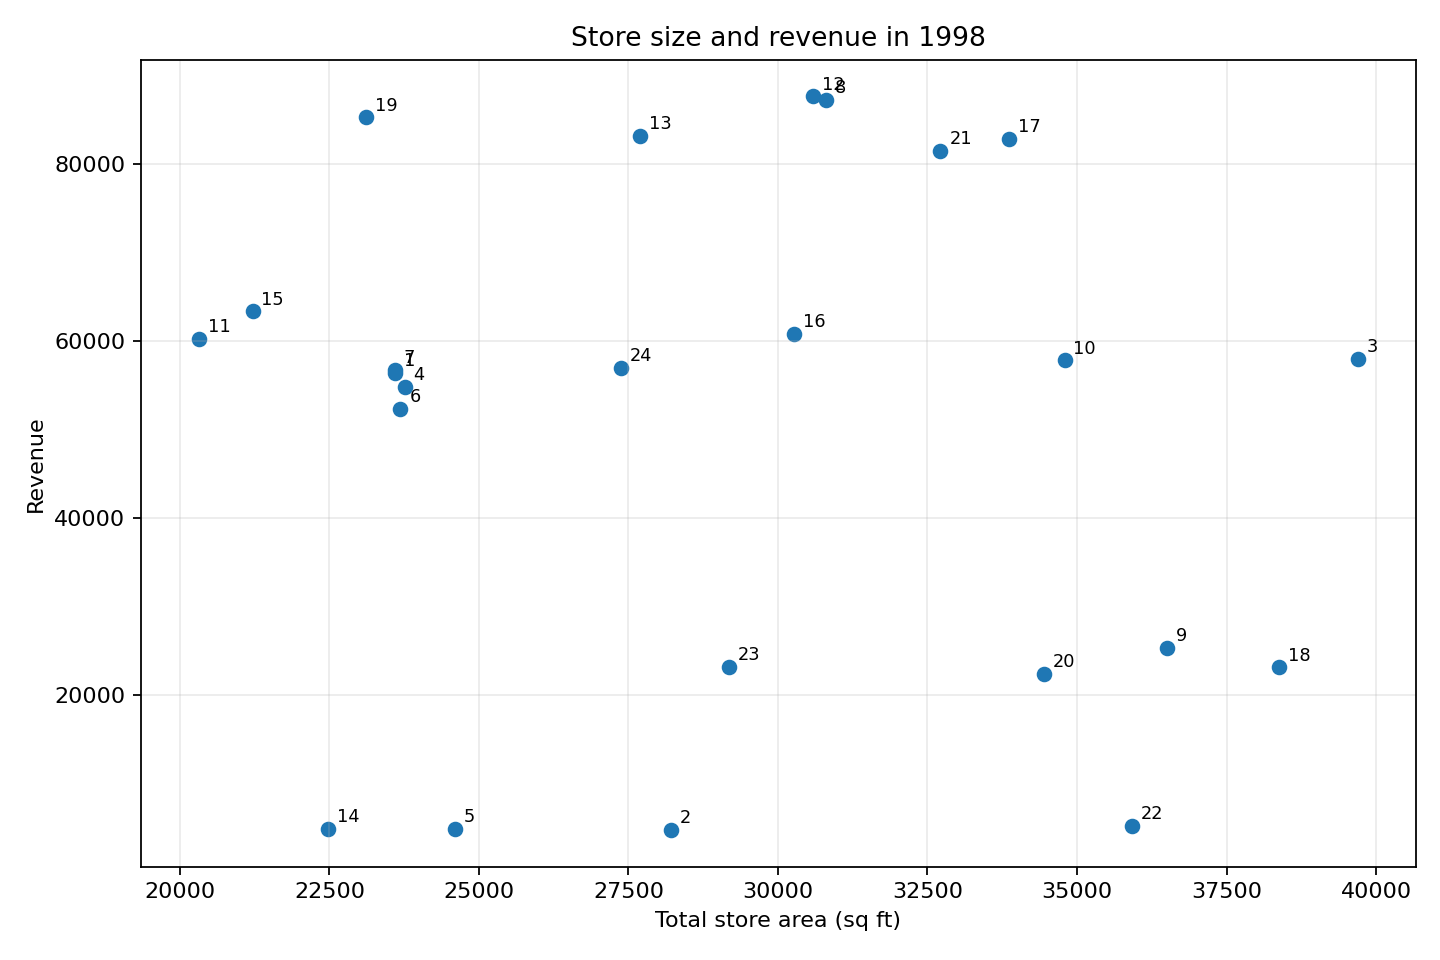

In [8]:
display(Image(filename=str(images_dir / "03_store_size_vs_revenue_1998.png")))

## Customer value

In [9]:
analysis_tables["customer_segment_performance"].sort_values("revenue_per_customer", ascending=False).round(2)

,member_card,revenue,gross_product_profit,quantity_sold,active_customers,revenue_per_customer,gross_margin_pct
1,Golden,223670.66,133451.79,106251,1018,219.72,59.66
0,Bronze,986502.65,588626.31,465090,4911,200.88,59.67
2,Normal,406875.66,242817.16,192265,2086,195.05,59.68
3,Silver,147497.47,87923.52,69883,827,178.35,59.61


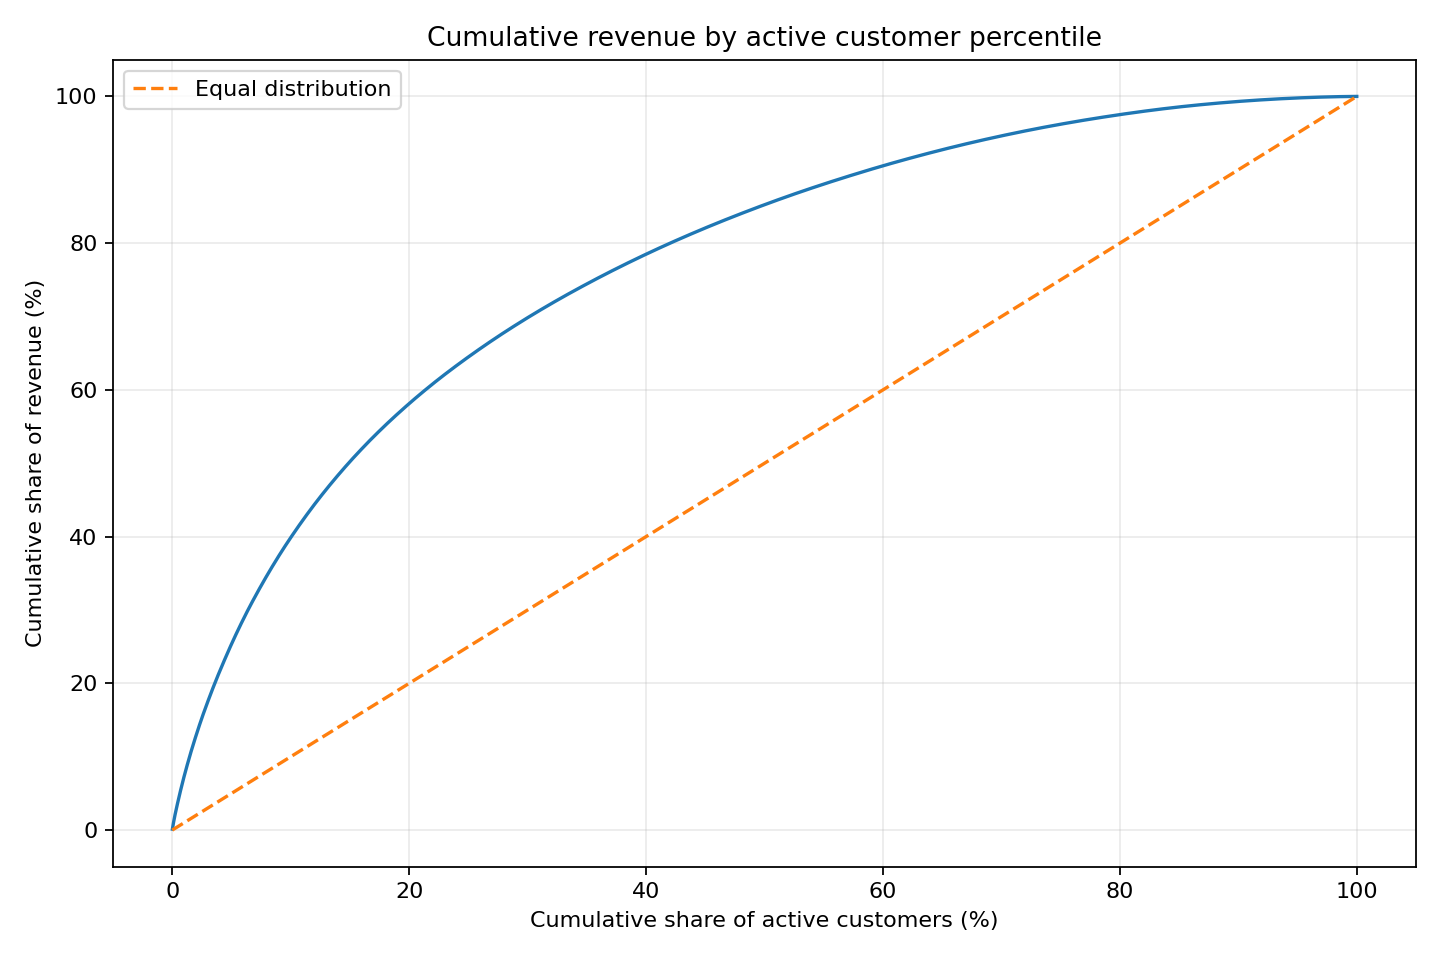

In [10]:
display(Image(filename=str(images_dir / "06_customer_revenue_concentration.png")))

## Return monitoring

In [11]:
analysis_tables["store_return_rates"].nlargest(10, "return_rate_pct")[["store_name", "store_country", "quantity_sold", "return_quantity", "return_rate_pct"]].round(3)

,store_name,store_country,quantity_sold,return_quantity,return_rate_pct
7,Store 8,Mexico,40994,480.0,1.171
19,Store 20,Canada,10600,121.0,1.142
22,Store 23,USA,22377,250.0,1.117
11,Store 12,Mexico,41808,460.0,1.100
15,Store 16,USA,52489,559.0,1.065
18,Store 19,Canada,40152,420.0,1.046
10,Store 11,USA,54526,564.0,1.034
23,Store 24,USA,52417,541.0,1.032
16,Store 17,USA,74347,764.0,1.028
17,Store 18,Mexico,11080,112.0,1.011


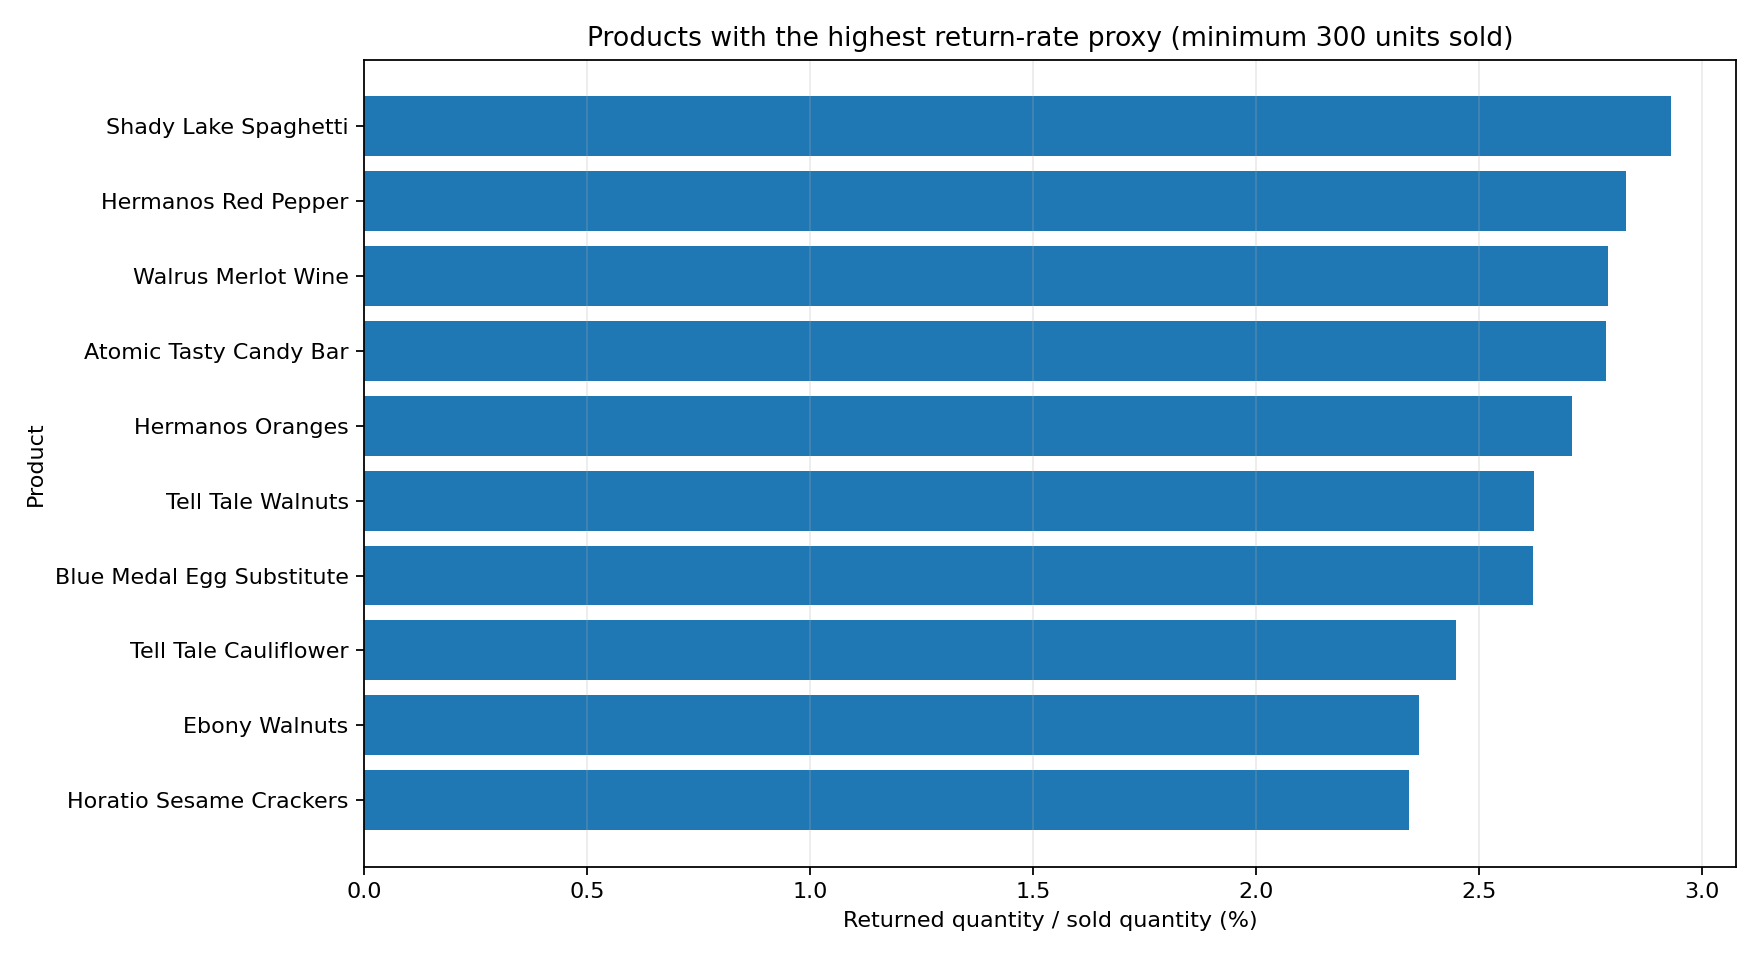

In [12]:
display(Image(filename=str(images_dir / "09_product_return_risk.png")))

## Takeaways

- The headline 1998 growth is dominated by store expansion; same-store growth is the better organic comparison.
- Gross margin is stable, so growth is mainly volume-driven.
- Store size alone does not explain revenue performance.
- Customer concentration and membership value are useful segmentation views.
- Return-rate proxies should be used as alerts, not as matched transaction return rates.

In [13]:
validation = json.loads((reports_dir / "eda_validation.json").read_text())
validation

{'status': 'passed',
 'checks': {'sales_rows_preserved': True,
  'revenue_reconciles': True,
  'profit_reconciles': True,
  'quantity_reconciles': True,
  'all_expected_charts_created': True,
  'annual_periods_present': True,
  'all_1998_stores_present': True},
 'generated_charts': ['01_monthly_revenue_profit.png',
  '02_reported_vs_same_store_growth.png',
  '03_store_size_vs_revenue_1998.png',
  '04_top_stores_revenue_1998.png',
  '05_top_brands_revenue.png',
  '06_customer_revenue_concentration.png',
  '07_member_card_revenue_per_customer.png',
  '08_store_return_rate.png',
  '09_product_return_risk.png']}